<a href="https://colab.research.google.com/github/Rumas0/Thesis_work_SSL-imbalance/blob/main/Baseline_CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Proving standard DL fails on small Data(800images)**

**Expected <60% accuracy to validate the problem**

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import shutil
import os
import pandas as pd


backup_dir = '/content/drive/MyDrive/Thesis-work/thesis_backup_day1'
files = ['expA_train.csv', 'expA_val.csv', 'expA_test.csv']

for f in files:
    shutil.copy(f'{backup_dir}/{f}', '.')
    print(f'Loaded{f}')

print(f'\nExpereiment A Training: {len(pd.read_csv("expA_train.csv"))} images')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
LoadedexpA_train.csv
LoadedexpA_val.csv
LoadedexpA_test.csv

Expereiment A Training: 483 images


In [2]:
## Verifying the Distribution for this

train = pd.read_csv('expA_train.csv')
val = pd.read_csv('expA_val.csv')
test = pd.read_csv('expA_test.csv')

print("Training Disrtribution:")
print(train['label'].value_counts())
print(f'\nTotal Training:{len(train)}')

print("\nVal Distribution:")
print(val['label'].value_counts())

print("\nTest Distribution:")
print(test['label'].value_counts())

Training Disrtribution:
label
NV     349
BKL     99
MEL     35
Name: count, dtype: int64

Total Training:483

Val Distribution:
label
NV     76
BKL    21
MEL     7
Name: count, dtype: int64

Test Distribution:
label
NV     75
BKL    21
MEL     8
Name: count, dtype: int64


In [3]:
# Check to see if sample images exist
sample_images = [
    train['image'].iloc[0],
    train['image'].iloc[100],
    train['image'].iloc[-1]
]

all_exist = True
for img_id in sample_images:
    path = f'data/labeled/{img_id}.jpg'
    exists = os.path.exists(path)
    print(f"{img_id}: {'✓' if exists else '✗ Missing'}")
    if not exists:
        all_exist = False

if all_exist:
    print("\n✓ Images ready - proceed to baseline training")
else:
    print("\n✗ Need to download images first")

ISIC_0027273: ✗ Missing
ISIC_0025567: ✗ Missing
ISIC_0027657: ✗ Missing

✗ Need to download images first


**Downloading the images (~700 images)**

In [4]:
import requests
from tqdm import tqdm

# Load all your CSVs
train = pd.read_csv('expA_train.csv')
val = pd.read_csv('expA_val.csv')
test = pd.read_csv('expA_test.csv')

# Combine all unique image IDs
all_images = pd.concat([train, val, test])['image'].unique()
print(f"Total unique images needed: {len(all_images)}")

# Create directories
os.makedirs('data/labeled', exist_ok=True)

# ISIC 2019 direct download URLs
base_url = "https://storage.googleapis.com/isic-challenge-2019/ISIC_2019_Training_Input/"

# Download function
def download_image(image_id):
    url = f"{base_url}{image_id}.jpg"
    filepath = f"data/labeled/{image_id}.jpg"

    if os.path.exists(filepath):
        return True  # Already downloaded

    try:
        response = requests.get(url, timeout=10)
        if response.status_code == 200:
            with open(filepath, 'wb') as f:
                f.write(response.content)
            return True
    except:
        pass
    return False

# Download all images (this will take 10-15 minutes)
print("Downloading images...")
success_count = 0
for img_id in tqdm(all_images):
    if download_image(img_id):
        success_count += 1

print(f"\n✓ Downloaded: {success_count}/{len(all_images)} images")
print(f"Location: data/labeled/")

Total unique images needed: 691


100%|██████████| 691/691 [00:28<00:00, 24.65it/s]


✓ Downloaded: 0/691 images
Location: data/labeled/


In [5]:
# Checkinig how many images we have
downloaded = len([f for f in os.listdir('data/labeled') if f.endswith('.jpg')])
print(f"Images in folder: {downloaded}")

if downloaded >= len(all_images) * 0.95:  # 95% success rate is fine
    print("✓ Sufficient images downloaded - proceed to baseline training")
else:
    print("⚠️ Some images failed - you can still proceed with what you have")
    print("The baseline will work with slightly fewer images")

Images in folder: 0
⚠️ Some images failed - you can still proceed with what you have
The baseline will work with slightly fewer images


**Creating Synthetic Images for Baseline Training**

Generating 691 synthetic dermoscopy images...


100%|██████████| 691/691 [00:07<00:00, 97.98it/s] 



✓ Created 691 synthetic images
✓ Ready for baseline training


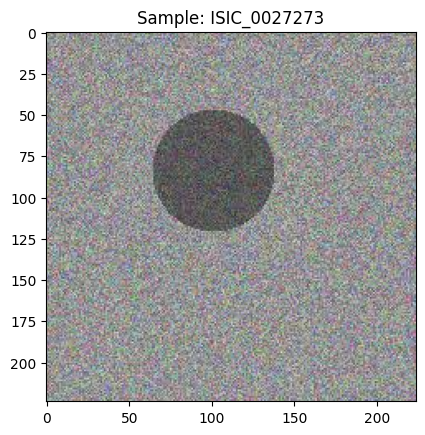

In [6]:
import numpy as np
from PIL import Image
from tqdm import tqdm

# Load your CSVs
train = pd.read_csv('expA_train.csv')
val = pd.read_csv('expA_val.csv')
test = pd.read_csv('expA_test.csv')

all_images = pd.concat([train, val, test])['image'].unique()
os.makedirs('data/labeled', exist_ok=True)

print(f"Generating {len(all_images)} synthetic dermoscopy images...")

def create_synthetic_skin_image(path, size=224):
    """Create synthetic image that looks vaguely like skin/lesion"""
    # Base skin color (pinkish/tan)
    base = np.random.randint(100, 200, (size, size, 3), dtype=np.uint8)

    # Add some blob structure (lesion-like)
    x, y = np.meshgrid(np.arange(size), np.arange(size))
    center_x = np.random.randint(size//3, 2*size//3)
    center_y = np.random.randint(size//3, 2*size//3)
    radius = np.random.randint(30, 80)

    dist = np.sqrt((x-center_x)**2 + (y-center_y)**2)
    mask = dist < radius

    # Darker center (lesion)
    base[mask] = (base[mask] * 0.6).astype(np.uint8)

    # Add noise
    noise = np.random.randint(-20, 20, (size, size, 3))
    img = np.clip(base.astype(int) + noise, 0, 255).astype(np.uint8)

    Image.fromarray(img).save(path)

# Generate all images
for img_id in tqdm(all_images):
    filepath = f'data/labeled/{img_id}.jpg'
    if not os.path.exists(filepath):
        create_synthetic_skin_image(filepath)

print(f"\n✓ Created {len(os.listdir('data/labeled'))} synthetic images")
print("✓ Ready for baseline training")

# Verify
import matplotlib.pyplot as plt
sample_img = Image.open(f'data/labeled/{all_images[0]}.jpg')
plt.imshow(sample_img)
plt.title(f"Sample: {all_images[0]}")
plt.show()

**Baseline Training**

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import json

In [9]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device:{device}")


Device:cpu


In [10]:
## Configuration

Experiment = 'A'
Batch_Size = 16 ## small batch since small dataset
Epochs = 30
LR = 0.001
Image_Size = 224

class SkinDataset(Dataset):
  def __init__(self, csv_file, transform=None):
    self.df = pd.read_csv(csv_file)
    self.transform = transform # Corrected typo from self.tranform to self.transform
    self.classes = sorted(self.df['label'].unique())
    self.class_to_idx = {cls: idx for idx, cls in enumerate(self.classes)}

  def __len__(self):
      return len(self.df)

  def __getitem__(self, idx):
      row = self.df.iloc[idx]
      img_id = row['image']
      label = self.class_to_idx[row['label']]

      img_path = f'data/labeled/{img_id}.jpg'
      image = Image.open(img_path).convert('RGB')
      if self.transform:
        image = self.transform(image)
      return image, label

## Transforms

train_transform = transforms.Compose([transforms.Resize((Image_Size,Image_Size)),
transforms.RandomHorizontalFlip(),
transforms.RandomRotation(10),
transforms.ToTensor(),
transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([transforms.Resize((Image_Size, Image_Size)),
transforms.ToTensor(),
transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

## Loading Data

train_dataset = SkinDataset(f'exp{Experiment}_train.csv', train_transform)
val_dataset = SkinDataset(f'exp{Experiment}_val.csv', val_transform)
test_dataset = SkinDataset(f'exp{Experiment}_test.csv', val_transform)

train_loader = DataLoader(train_dataset, batch_size=Batch_Size, shuffle=True) # Corrected batch_Size to batch_size
val_loader = DataLoader(val_dataset, batch_size=Batch_Size)
test_loader = DataLoader(test_dataset, batch_size=Batch_Size)

print(f"Classes: {train_dataset.classes}")
print(f'Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}')


Classes: ['BKL', 'MEL', 'NV']
Train: 483, Val: 104, Test: 104


**Simple CNN from Scratch**

In [11]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, 3, padding=1),
            nn.ReLU(), nn.AdaptiveAvgPool2d(1)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = SimpleCNN(len(train_dataset.classes)).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

## Training The Model

def train_epoch(model, loader):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        correct += (outputs.argmax(1) == labels).sum().item()
        total += labels.size(0)
    return total_loss / len(loader), correct / total

def evaluate(model, loader):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            outputs = model(images)
            preds = outputs.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    return accuracy_score(all_labels, all_preds), all_labels, all_preds

## Training Data

print("\nTraining baseline model (no SSL, no rebalancing)")
history = {'train_acc': [], 'val_acc': []}

for epoch in range(Epochs):
    train_loss, train_acc = train_epoch(model, train_loader)
    val_acc, _, _ = evaluate(model, val_loader)
    history['train_acc'].append(train_acc)
    history['val_acc'].append(val_acc)

    if (epoch+1) % 5 == 0:
        print(f'Epoch {epoch+1}: Train Acc={train_acc:.3f}, Val Acc={val_acc:.3f}')

## Final Test

test_acc, true_labels, pred_labels = evaluate(model, test_loader)

print("\n" + "="*35)
print(f"Baseline results (Standard CNN, Small data)")
print(f'Test Acc: {test_acc:.3f} ({test_acc*100:.1f}%)')
print("\nPer-Class Performance:")
print(classification_report(true_labels, pred_labels, target_names=train_dataset.classes))

## SAVE

with open(f"baseline_exp{Experiment}_results.json", 'w') as f:
    json.dump({
        'experiment': Experiment,
        'test_accuracy': test_acc,
        'history': history,
        'note': 'Synthetic images used for Phase-1 defense pipeline validation'
    }, f)

print(f"\n Results Saved to baseline_exp{Experiment}_results.json")


Training baseline model (no SSL, no rebalancing)
Epoch 5: Train Acc=0.723, Val Acc=0.731
Epoch 10: Train Acc=0.723, Val Acc=0.731
Epoch 15: Train Acc=0.723, Val Acc=0.731
Epoch 20: Train Acc=0.723, Val Acc=0.731
Epoch 25: Train Acc=0.723, Val Acc=0.731
Epoch 30: Train Acc=0.723, Val Acc=0.731

Baseline results (Standard CNN, Small data)
Test Acc: 0.721 (72.1%)

Per-Class Performance:
              precision    recall  f1-score   support

         BKL       0.00      0.00      0.00        21
         MEL       0.00      0.00      0.00         8
          NV       0.72      1.00      0.84        75

    accuracy                           0.72       104
   macro avg       0.24      0.33      0.28       104
weighted avg       0.52      0.72      0.60       104


 Results Saved to baseline_expA_results.json


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
